### Top competing peak per eqC1 injection-recovery target

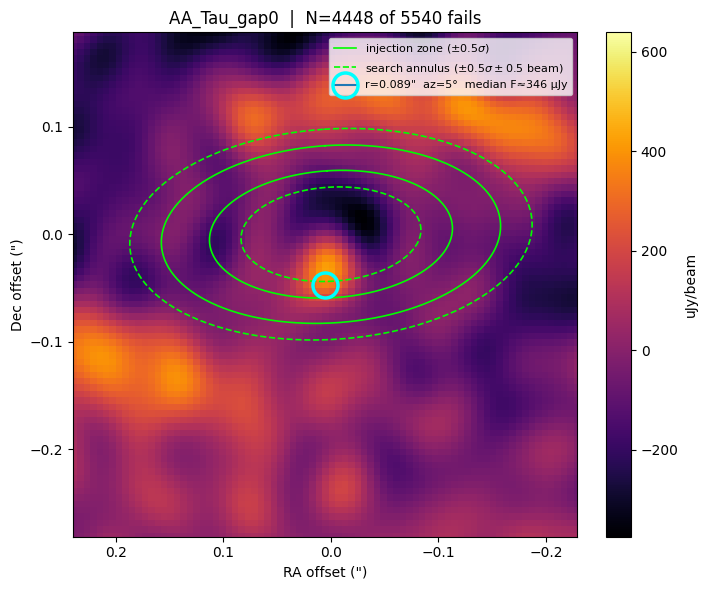

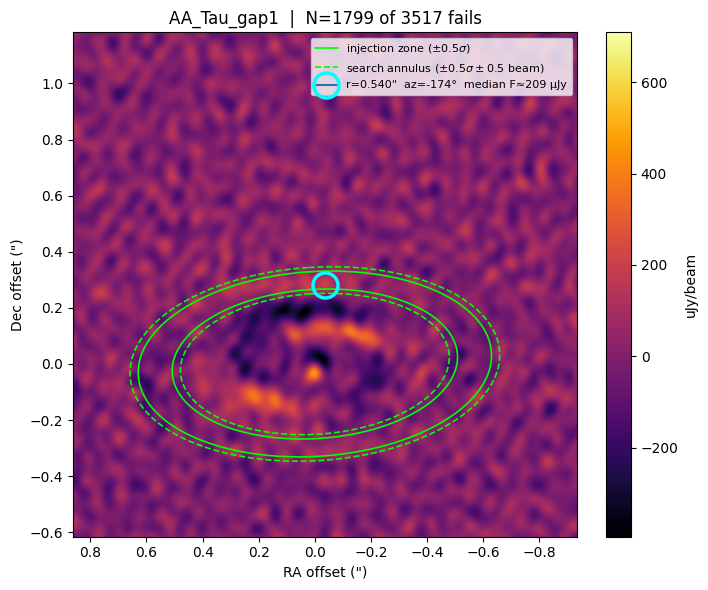

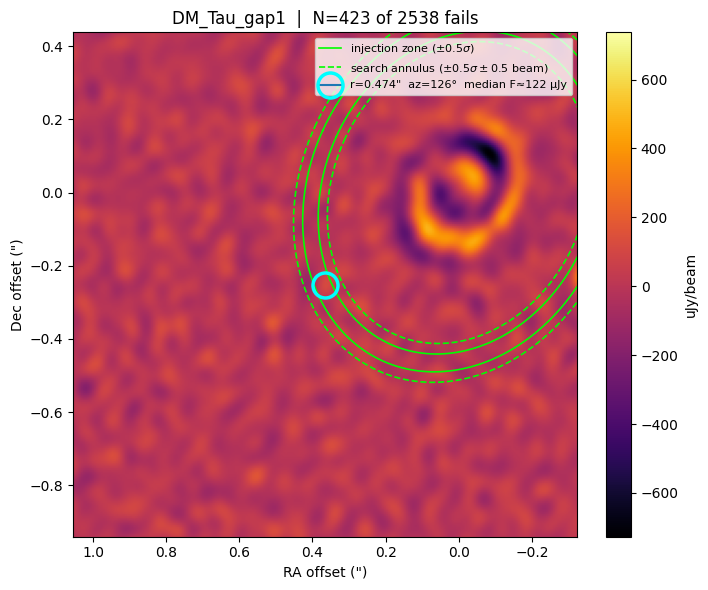

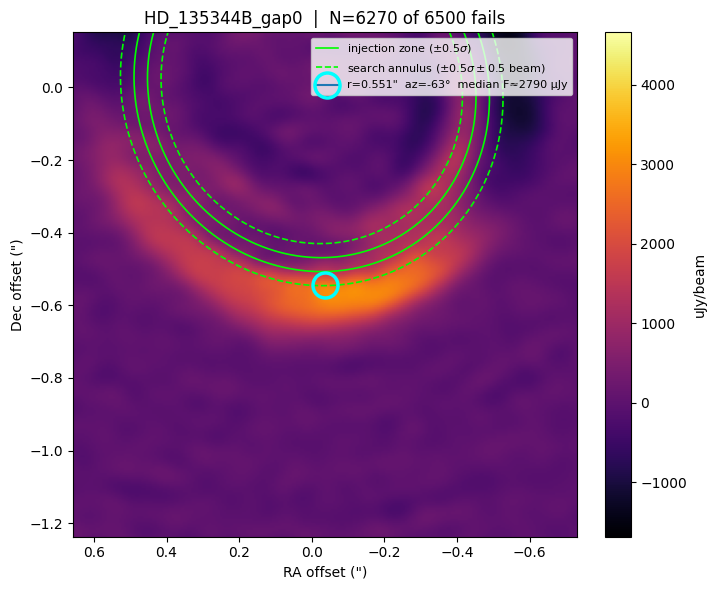

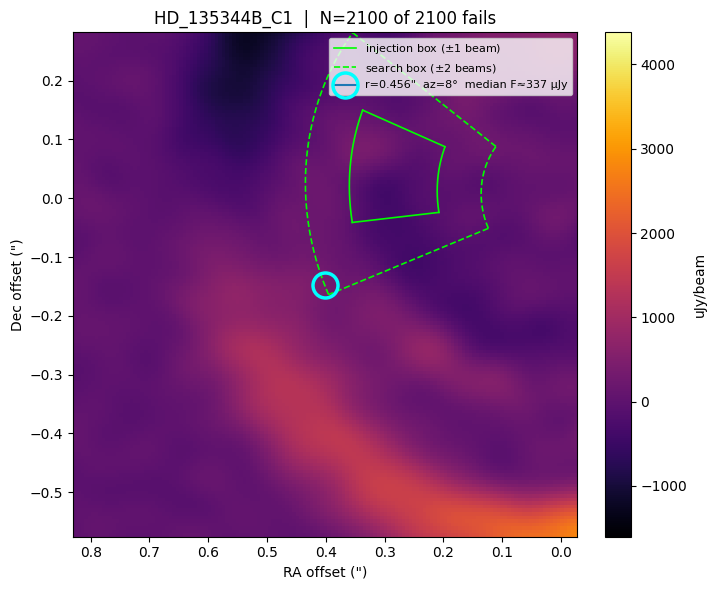

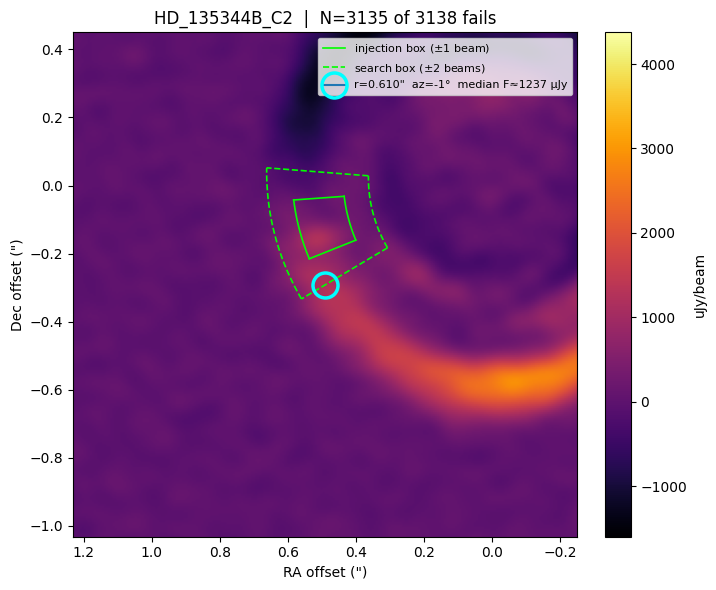

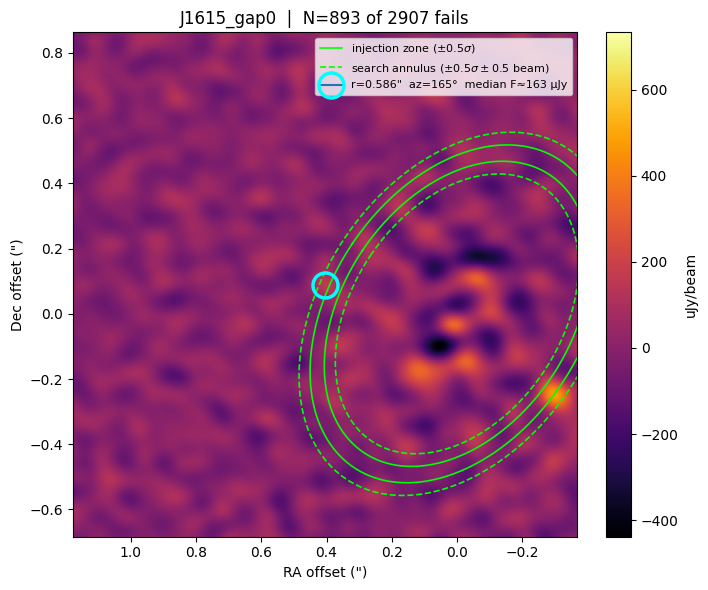

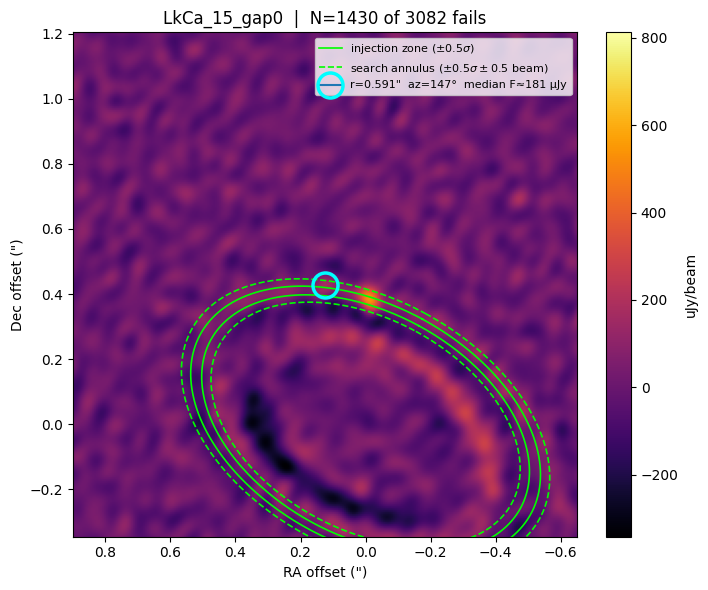

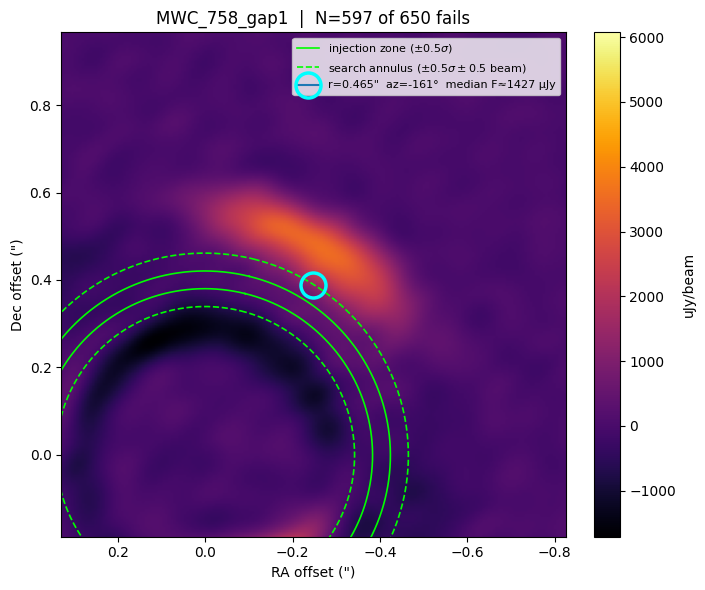

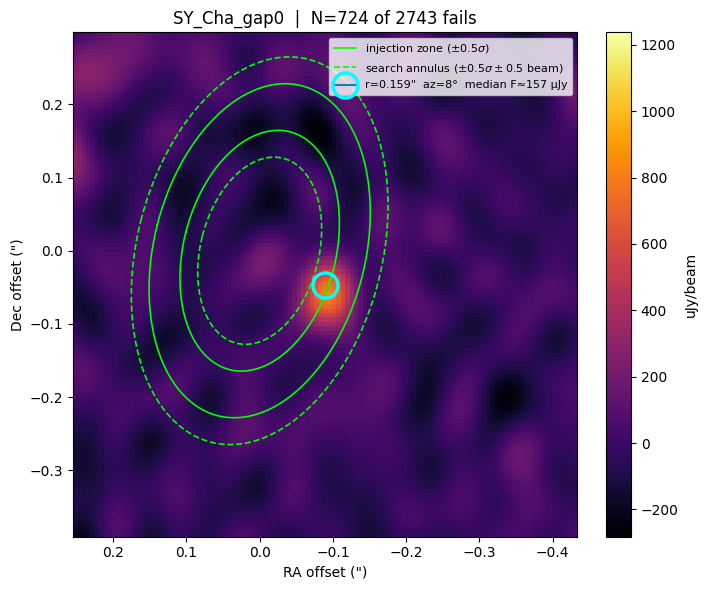

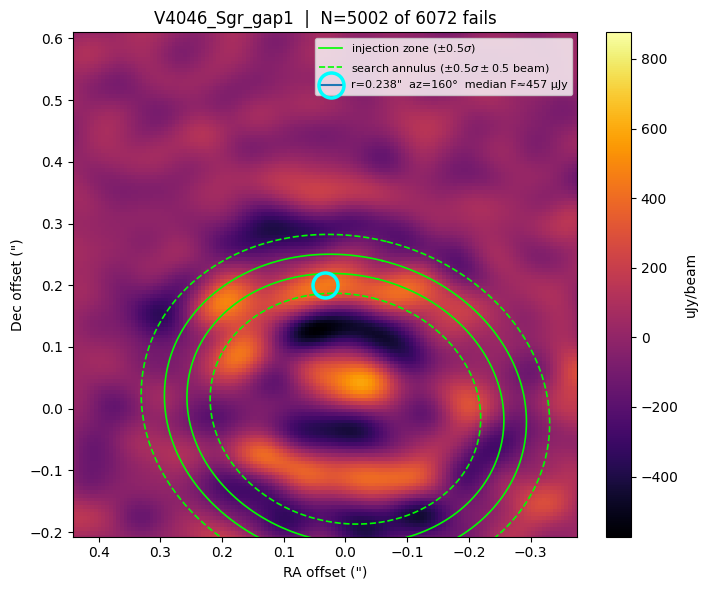

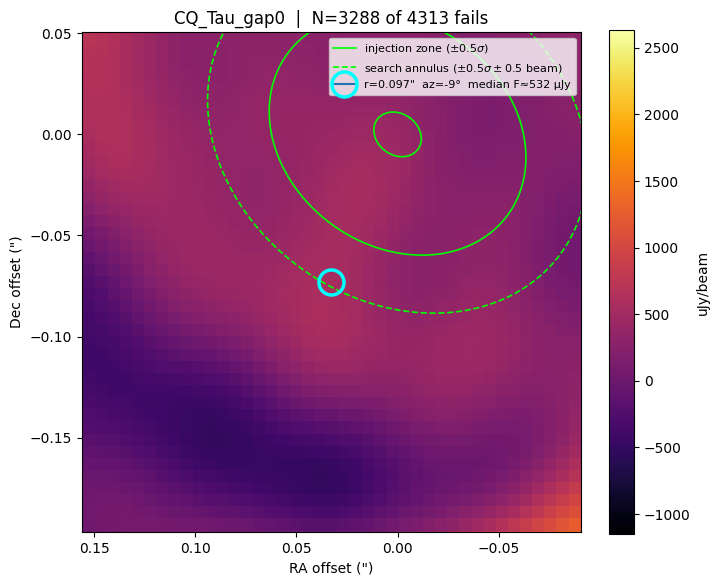

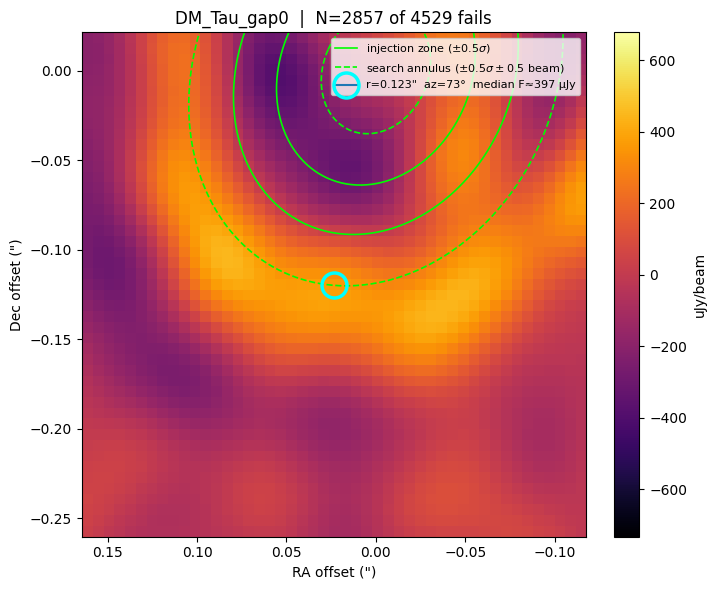

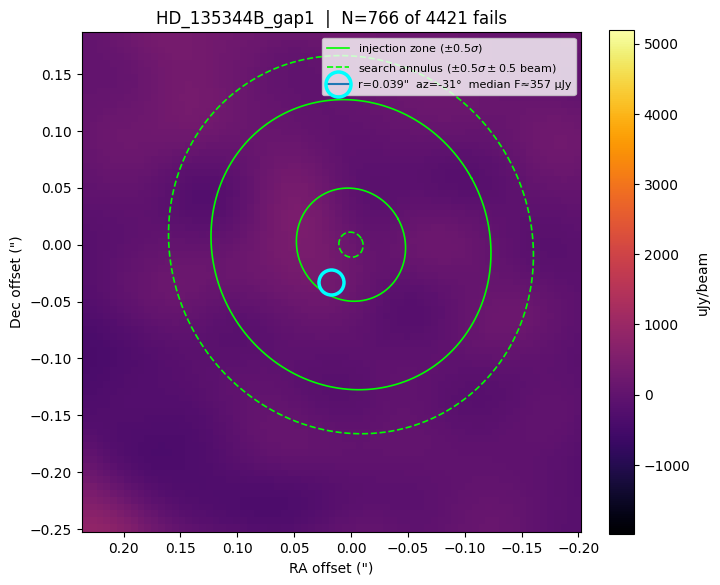

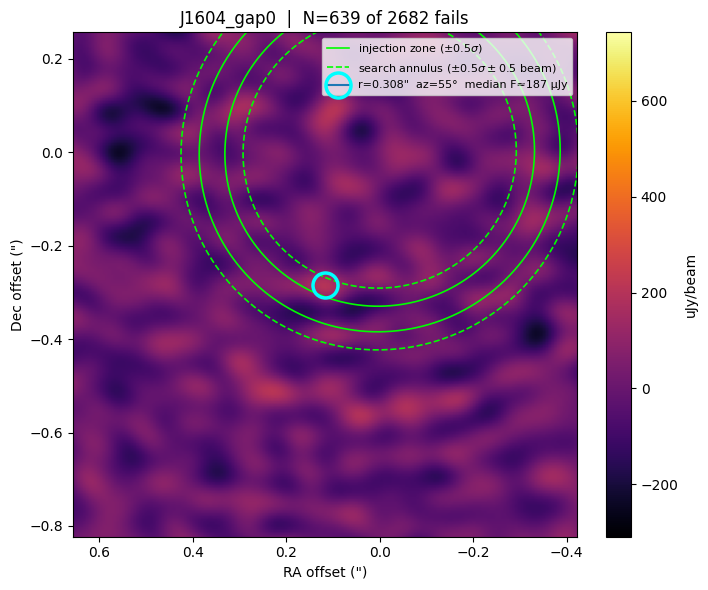

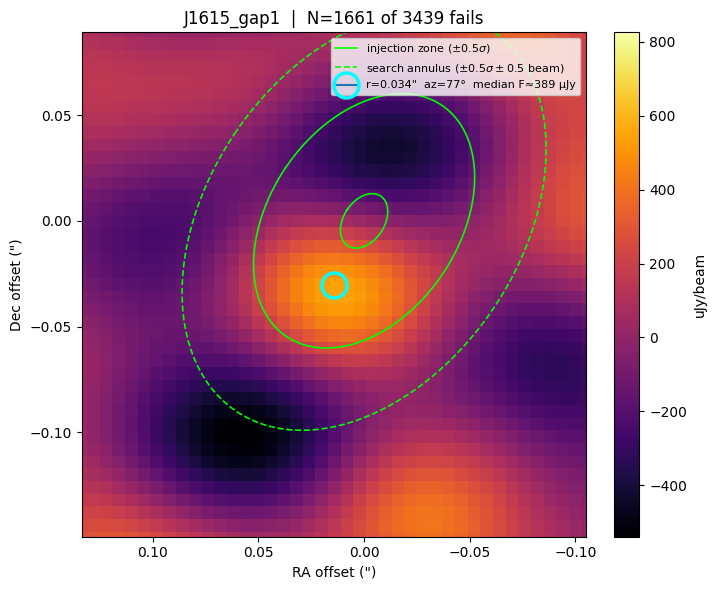

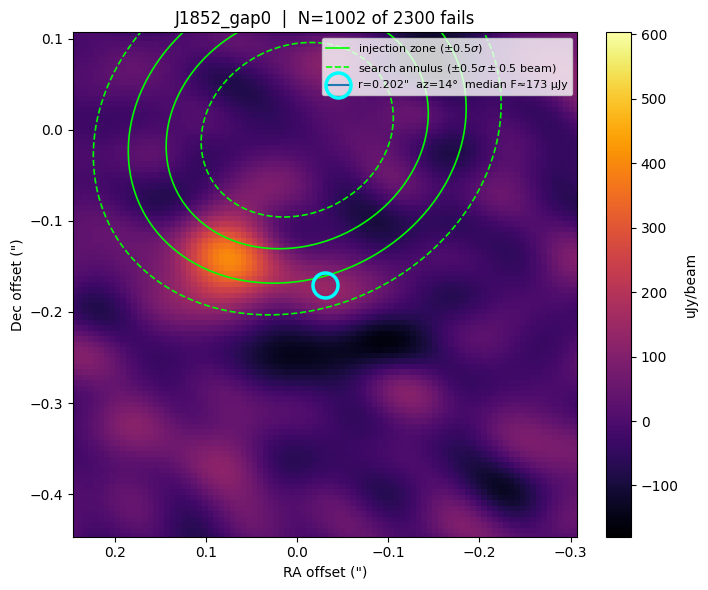

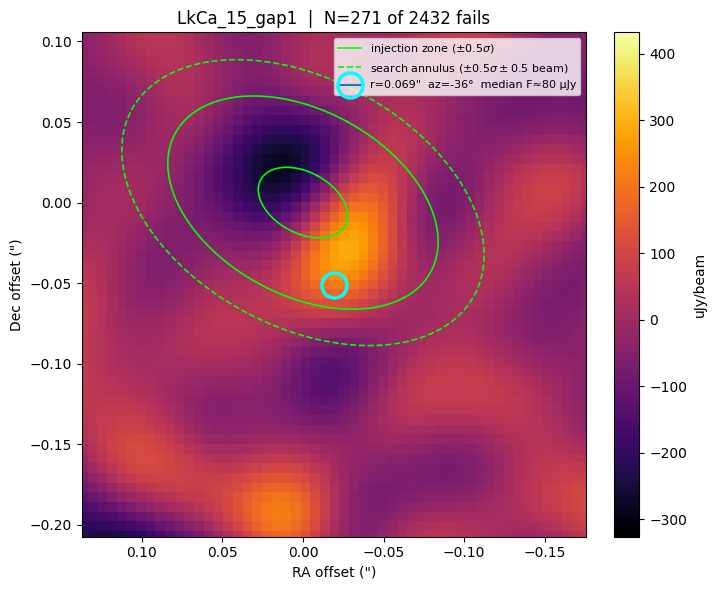

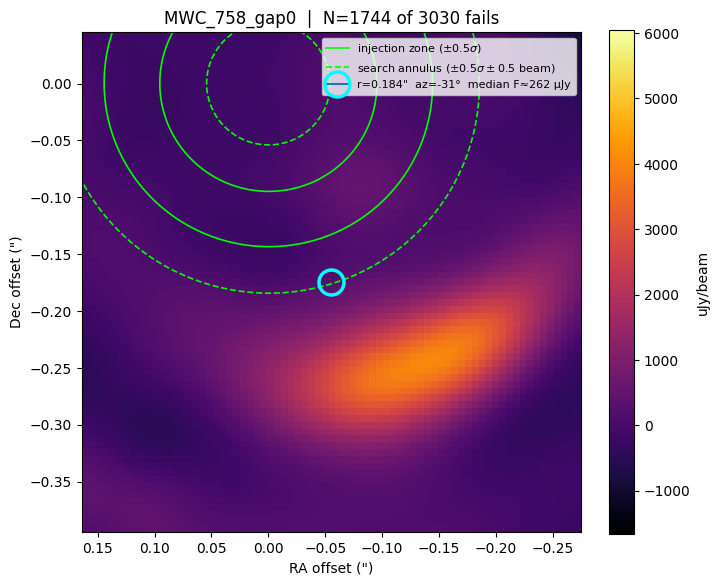

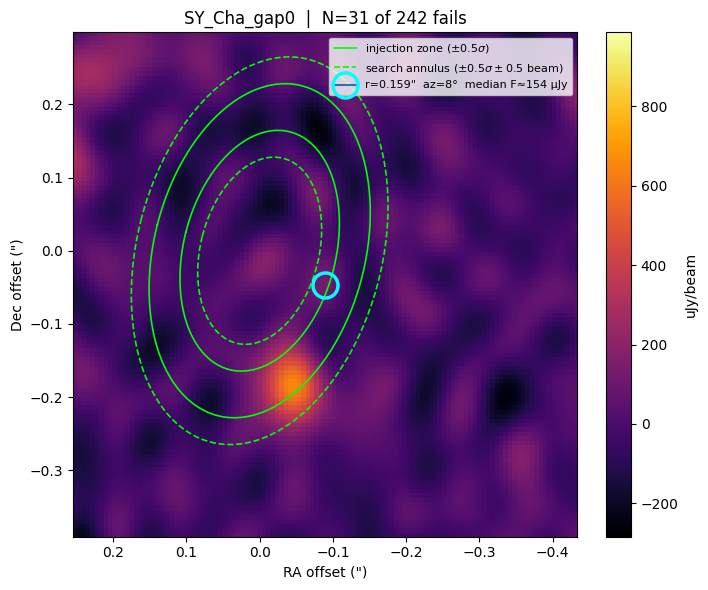

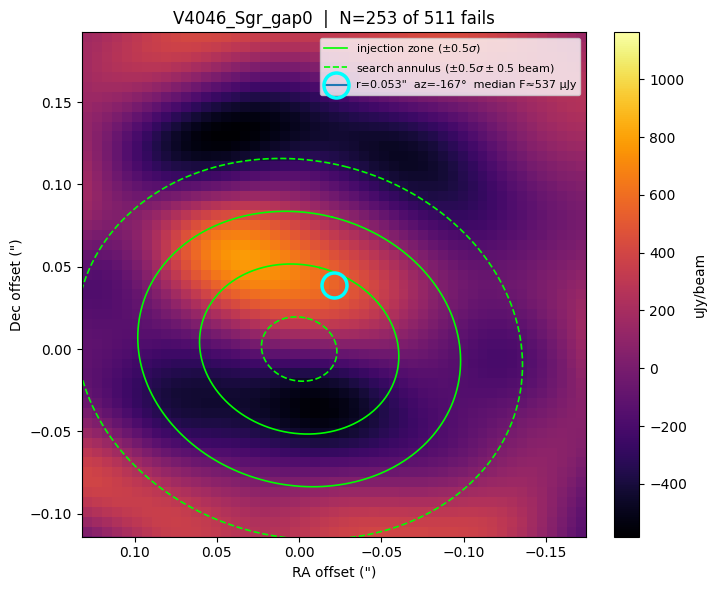

In [5]:
# for every eqC1 injection-recovery target: zoom centred on the top competing peak (most common
# criterion-A failed recovery position), with the injection region (solid)
# and the recover_loop.py search region (dashed) drawn on the first injected residual image
import glob, os, sys
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

sys.path.append(r"d:\CPD_MPIA\HPC_eqC1_gap")
import diskdictionary_eqC1 as disk

npix_tol, ast_tol = 2, 2
vmax_fac = 1.5    # colour scale vmax = vmax_fac * image max

folders = ['gap/AA_Tau_gap0', 'gap/AA_Tau_gap1', 'gap/DM_Tau_gap1', 'gap/HD_135344B_gap0',
           'gap/HD_135344B_C1', 'gap/HD_135344B_C2', 'gap/J1615_gap0',
           'gap/LkCa_15_gap0', 'gap/MWC_758_gap1', 'gap/SY_Cha_gap0', 'gap/V4046_Sgr_gap1',
           'inner_cavity/CQ_Tau_gap0', 'inner_cavity/DM_Tau_gap0', 'inner_cavity/HD_135344B_gap1',
           'inner_cavity/J1604_gap0', 'inner_cavity/J1615_gap1', 'inner_cavity/J1852_gap0',
           'inner_cavity/LkCa_15_gap1', 'inner_cavity/MWC_758_gap0', 'inner_cavity/SY_Cha_gap0',
           'inner_cavity/V4046_Sgr_gap0']

# HD_135344B point candidates (R", az deg): injected within +/-1 beam, searched within +/-2 beams
# (DF left out: every DF injection passes criterion A, so it has no competing peak)
candidates = {'gap/HD_135344B_C1': (0.30, 36.0), 'gap/HD_135344B_C2': (0.54, 15.0)}

top_peaks = {}   # folder -> (target, gap_ix, r", median recovered flux uJy) of the top competing peak

def polar_to_sky(r, az, inclr, PAr):
    azr = np.radians(az)
    return (r * np.sin(azr) * np.sin(PAr) + r * np.cos(azr) * np.cos(inclr) * np.cos(PAr),
            r * np.sin(azr) * np.cos(PAr) - r * np.cos(azr) * np.cos(inclr) * np.sin(PAr))

for folder in folders:
    rec_file = (glob.glob(folder + '/recoveries/*_recoveries.combined.txt') +
                glob.glob(folder + '/recoveries/*_recoveries.0.txt'))[0]
    target, gap_ix = os.path.basename(rec_file).split('_recoveries')[0].rsplit('_gap', 1)
    d = disk.disk[target]
    inclr, PAr = np.radians(d['incl']), np.radians(d['PA'])
    rgap, wgap = d['rgap'][int(gap_ix)], d['wgap'][int(gap_ix)]

    Fi, Fr, mdl, ri, rr, azi, azr, xr, yr, mu, rms = np.loadtxt(rec_file).T
    img_file = sorted(glob.glob(folder + '/recoveries/*.resid.fits'))[0]
    img = 1e6 * np.squeeze(fits.getdata(img_file))
    hd = fits.getheader(img_file)
    beam_fwhm = np.sqrt(3600**2 * hd['BMAJ'] * hd['BMIN'])

    # criterion A (Reid et al. 1988) recovery, then the most common failed peak position (r, az);
    # grouped by position only, since the same pixel's flux shifts slightly between injected images
    xi, yi = polar_to_sky(ri, azi, inclr, PAr)
    sigma_A = (4 / np.pi)**0.25 * beam_fwhm * rms / (np.sqrt(8 * np.log(2)) * Fr)
    is_rec = np.hypot(xi - xr, yi - yr) <= np.maximum(ast_tol * sigma_A, npix_tol * 3600 * abs(hd['CDELT2']))
    vals, idx, inv, cts = np.unique(np.stack((rr, azr), axis=-1)[~is_rec], axis=0,
                                    return_index=True, return_inverse=True, return_counts=True)
    k = np.argmax(cts)
    mark_r, mark_az = vals[k]
    mark_F = np.median(Fr[~is_rec][inv.ravel() == k])
    mark_x, mark_y = xr[~is_rec][idx[k]], yr[~is_rec][idx[k]]
    top_peaks[folder] = (target, int(gap_ix), mark_r, mark_F)

    X = 3600 * hd['CDELT1'] * (np.arange(hd['NAXIS1']) - (hd['CRPIX1'] - 1)) - d['dx']
    Y = 3600 * hd['CDELT2'] * (np.arange(hd['NAXIS2']) - (hd['CRPIX2'] - 1)) - d['dy']
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(img, origin='lower', cmap='inferno', extent=[X[0], X[-1], Y[0], Y[-1]],
                   vmax=vmax_fac * img.max())

    # (r_in, r_out, az half-width, linestyle, label) for the injection and search regions
    if folder in candidates:
        R, AZ = candidates[folder]
        regions = [(R - beam_fwhm, R + beam_fwhm, np.degrees(beam_fwhm / R), '-', r'injection box ($\pm1$ beam)'),
                   (R - 2 * beam_fwhm, R + 2 * beam_fwhm, np.degrees(2 * beam_fwhm / R), '--', r'search box ($\pm2$ beams)')]
    else:
        AZ, s = 0, 0.5 * wgap + 0.5 * beam_fwhm
        regions = [(rgap - 0.5 * wgap, rgap + 0.5 * wgap, 180, '-', r'injection zone ($\pm0.5\sigma$)'),
                   (rgap - s, rgap + s, 180, '--', r'search annulus ($\pm0.5\sigma\pm0.5$ beam)')]
    for r1, r2, da, ls, lab in regions:
        az = np.linspace(AZ - da, AZ + da, 361)
        r1 = max(r1, 0)    # inner-cavity search annuli reach the centre
        ax.plot(*polar_to_sky(r1, az, inclr, PAr), color='lime', ls=ls, lw=1.2, label=lab)
        ax.plot(*polar_to_sky(r2, az, inclr, PAr), color='lime', ls=ls, lw=1.2)
        if folder in candidates:
            for a in (AZ - da, AZ + da):
                ax.plot(*polar_to_sky(np.array([r1, r2]), a, inclr, PAr), color='lime', ls=ls, lw=1.2)

    ax.plot(mark_x, mark_y, marker='o', markerfacecolor='none', markeredgecolor='cyan', markersize=18,
            markeredgewidth=2.5, label=f'r={mark_r:.3f}"  az={mark_az:.0f}\u00b0  median F\u2248{mark_F:.0f} \u00b5Jy')
    zoom = 1.3 * (rgap + wgap)
    ax.set_xlim(mark_x + zoom, mark_x - zoom)
    ax.set_ylim(mark_y - zoom, mark_y + zoom)
    ax.set_xlabel('RA offset (")')
    ax.set_ylabel('Dec offset (")')
    ax.set_title(f'{folder.split("/")[1]}  |  N={cts[k]} of {(~is_rec).sum()} fails')
    plt.colorbar(im, ax=ax, fraction=0.046, label='uJy/beam')
    ax.legend(fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.show()

<>:73: SyntaxWarning: invalid escape sequence '\s'
<>:74: SyntaxWarning: invalid escape sequence '\s'
<>:73: SyntaxWarning: invalid escape sequence '\s'
<>:74: SyntaxWarning: invalid escape sequence '\s'
C:\Users\LHEM\AppData\Local\Temp\ipykernel_36176\1417792118.py:73: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f'robust {rob}  |  rms={img_rms:.1f} uJy/bm  peak={g.amplitude.value / img_rms:.1f}$\sigma$', fontsize=10)
C:\Users\LHEM\AppData\Local\Temp\ipykernel_36176\1417792118.py:74: SyntaxWarning: invalid escape sequence '\s'
  plt.colorbar(im, ax=ax, fraction=0.046, label='SNR ($\sigma$)')


robust  rms(uJy/bm)  peak(uJy/bm)  peak/rms  F_int(uJy)  FWHM fit maj x min (")  beam maj x min (")   x, y (")
 -2.0       63.6        93.0        1.5       86.5      0.082 x 0.063         0.086 x 0.065      -0.057, -0.059
 -1.5       64.4       104.0        1.6       88.6      0.084 x 0.057         0.087 x 0.065      -0.059, -0.062
 -1.0       62.3        99.4        1.6       93.3      0.082 x 0.066         0.087 x 0.065      -0.058, -0.058
 -0.5       54.2       112.2        2.1      106.7      0.095 x 0.063         0.091 x 0.068      -0.050, -0.050
  0.0       40.2       108.5        2.7      103.2      0.109 x 0.071         0.103 x 0.078      -0.043, -0.055
  0.5       31.5        95.3        3.0       95.9      0.117 x 0.107         0.128 x 0.097      -0.041, -0.078
  1.0       27.4        78.0        2.8       59.7      0.176 x 0.091         0.169 x 0.123      -0.039, -0.096
  1.5       26.5        71.5        2.7       31.6      0.158 x 0.080         0.203 x 0.142      -0.039, 

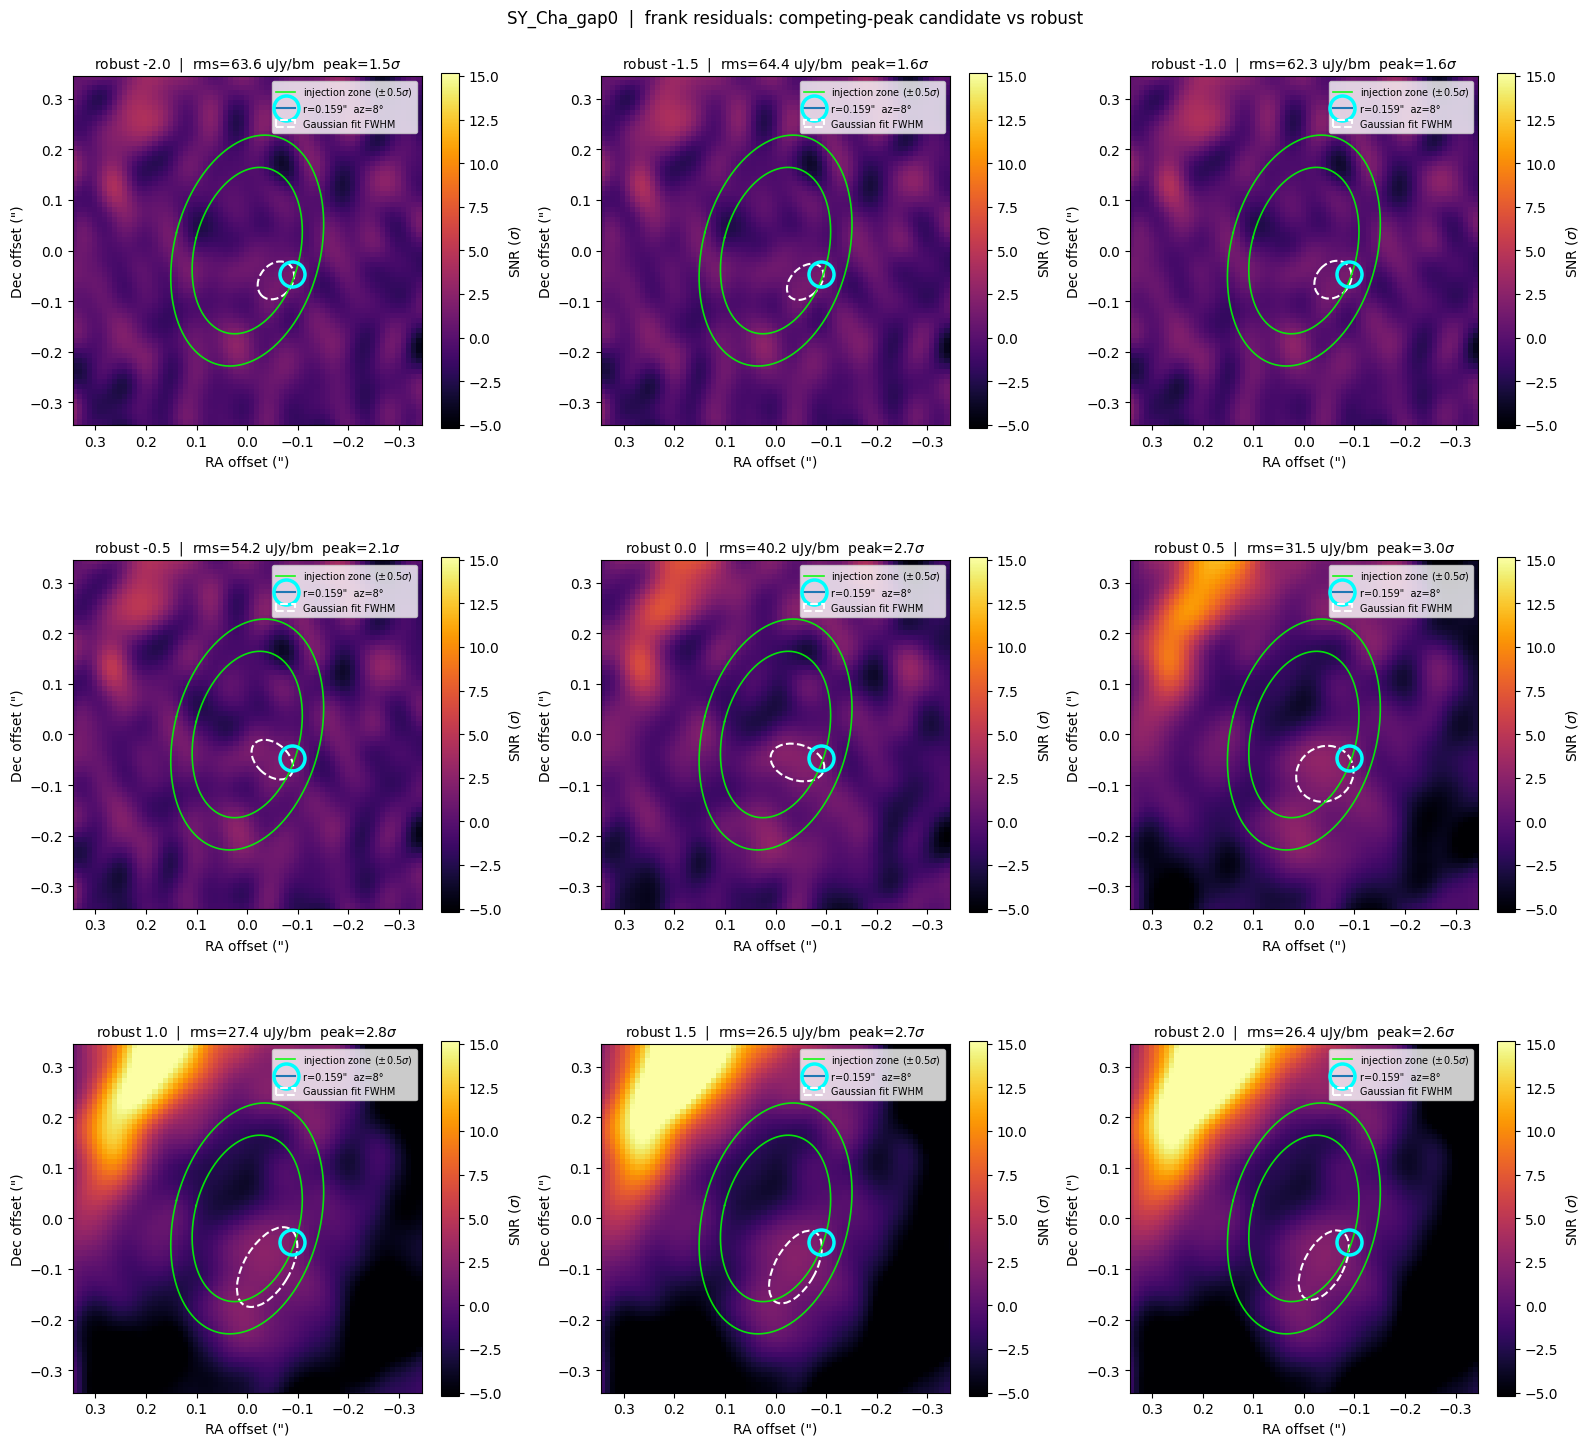

In [6]:
# robust series for one target: the frank residual image at every robust value, in units of each
# image's rms, with the injection zone and the top competing peak (as above), plus a 2D Gaussian
# fit to the peak at the marked position
from astropy.modeling import models, fitting
from matplotlib.patches import Ellipse

folder = 'gap/SY_Cha_gap0'

rec_file = (glob.glob(folder + '/recoveries/*_recoveries.combined.txt') +
            glob.glob(folder + '/recoveries/*_recoveries.0.txt'))[0]
target, gap_ix = os.path.basename(rec_file).split('_recoveries')[0].rsplit('_gap', 1)
d = disk.disk[target]
inclr, PAr = np.radians(d['incl']), np.radians(d['PA'])
rgap, wgap = d['rgap'][int(gap_ix)], d['wgap'][int(gap_ix)]

Fi, Fr, mdl, ri, rr, azi, azr, xr, yr, mu, rms = np.loadtxt(rec_file).T
img_file = sorted(glob.glob(folder + '/recoveries/*.resid.fits'))[0]
img = 1e6 * np.squeeze(fits.getdata(img_file))
hd = fits.getheader(img_file)
beam_fwhm = np.sqrt(3600**2 * hd['BMAJ'] * hd['BMIN'])

xi, yi = polar_to_sky(ri, azi, inclr, PAr)
sigma_A = (4 / np.pi)**0.25 * beam_fwhm * rms / (np.sqrt(8 * np.log(2)) * Fr)
is_rec = np.hypot(xi - xr, yi - yr) <= np.maximum(ast_tol * sigma_A, npix_tol * 3600 * abs(hd['CDELT2']))
vals, idx, cts = np.unique(np.stack((rr, azr), axis=-1)[~is_rec], axis=0, return_index=True, return_counts=True)
k = np.argmax(cts)
mark_r, mark_az = vals[k]
mark_x, mark_y = xr[~is_rec][idx[k]], yr[~is_rec][idx[k]]

az_tr = np.linspace(-180, 180, 361)
rzoom = 1.3 * (rgap + wgap)   # arcsec, half-width of each panel

rob_files = sorted(glob.glob(rf'D:/exoALMA_disk_data/{target}/images_frank_residuals_different_robust/*.fits'),
                   key=lambda f: float(f.split('robust')[-1][:-11]))

print('robust  rms(uJy/bm)  peak(uJy/bm)  peak/rms  F_int(uJy)  FWHM fit maj x min (")  beam maj x min (")   x, y (")')
fig, axes = plt.subplots(3, 3, figsize=(16, 15))
for ax, f in zip(axes.flat, rob_files):
    rob = f.split('robust')[-1][:-11]
    rhd = fits.getheader(f)
    rimg = 1e6 * np.squeeze(fits.getdata(f))
    X = 3600 * rhd['CDELT1'] * (np.arange(rhd['NAXIS1']) - (rhd['CRPIX1'] - 1)) - d['dx']
    Y = 3600 * rhd['CDELT2'] * (np.arange(rhd['NAXIS2']) - (rhd['CRPIX2'] - 1)) - d['dy']
    XX, YY = np.meshgrid(X, Y)
    bmaj, bmin = 3600 * rhd['BMAJ'], 3600 * rhd['BMIN']
    # image rms from an emission-free annulus 1.5-3" from the disk centre
    R = np.hypot(XX, YY)
    img_rms = np.std(rimg[(R > 1.5) & (R < 3)])

    # brightest pixel within 0.05" of the mark; Gaussian fit within one beam of it, centre kept within 0.05" of the mark
    j = np.argmax(np.where(np.hypot(XX - mark_x, YY - mark_y) <= 0.05, rimg, -np.inf))
    cut = np.hypot(XX - XX.flat[j], YY - YY.flat[j]) <= np.sqrt(bmaj * bmin)
    g0 = models.Gaussian2D(rimg.flat[j], XX.flat[j], YY.flat[j], bmaj / 2.3548, bmin / 2.3548, 0,
                           bounds={'x_mean': (mark_x - 0.05, mark_x + 0.05), 'y_mean': (mark_y - 0.05, mark_y + 0.05)})
    g = fitting.TRFLSQFitter()(g0, XX[cut], YY[cut], rimg[cut])
    fwx, fwy = 2.3548 * abs(g.x_stddev.value), 2.3548 * abs(g.y_stddev.value)
    Fint = g.amplitude.value * fwx * fwy / (bmaj * bmin)
    print(f'{rob:>5}   {img_rms:8.1f}    {g.amplitude.value:8.1f}     {g.amplitude.value / img_rms:6.1f}   {Fint:8.1f}      '
          f'{max(fwx, fwy):.3f} x {min(fwx, fwy):.3f}         {bmaj:.3f} x {bmin:.3f}      {g.x_mean.value:+.3f}, {g.y_mean.value:+.3f}')

    im = ax.imshow(rimg / img_rms, origin='lower', cmap='inferno', extent=[X[0], X[-1], Y[0], Y[-1]],
                   vmin=img.min() / d['RMS'], vmax=img.max() / d['RMS'])
    ax.plot(*polar_to_sky(rgap - 0.5 * wgap, az_tr, inclr, PAr), color='lime', lw=1.2, alpha=0.9, label=r'injection zone ($\pm0.5\sigma$)')
    ax.plot(*polar_to_sky(rgap + 0.5 * wgap, az_tr, inclr, PAr), color='lime', lw=1.2, alpha=0.9)
    ax.plot(mark_x, mark_y, marker='o', markerfacecolor='none', markeredgecolor='cyan', markersize=18, markeredgewidth=2.5,
            label=f'r={mark_r:.3f}"  az={mark_az:.0f}\u00b0')
    ax.add_patch(Ellipse((g.x_mean.value, g.y_mean.value), fwx, fwy, angle=np.degrees(g.theta.value),
                         fill=False, color='w', ls='--', lw=1.5, label='Gaussian fit FWHM'))
    ax.set_xlim(rzoom, -rzoom)
    ax.set_ylim(-rzoom, rzoom)
    ax.set_xlabel('RA offset (")')
    ax.set_ylabel('Dec offset (")')
    ax.set_title(f'robust {rob}  |  rms={img_rms:.1f} uJy/bm  peak={g.amplitude.value / img_rms:.1f}$\sigma$', fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, label='SNR ($\sigma$)')
    ax.legend(fontsize=7)
fig.suptitle(f'{folder.split("/")[1]}  |  frank residuals: competing-peak candidate vs robust')
plt.tight_layout()
plt.show()

[['J1852', 30, np.float64(173.0)]]


D:\CPD_MPIA\CPD_Emission_Models\Andrew_model.py:369: RuntimeWarning: divide by zero encountered in log10
  np.log10(M_cpd_chosen),


logMp_limit = 4.365007884251926 xlim = (np.float64(-2.0), np.float64(1.0))


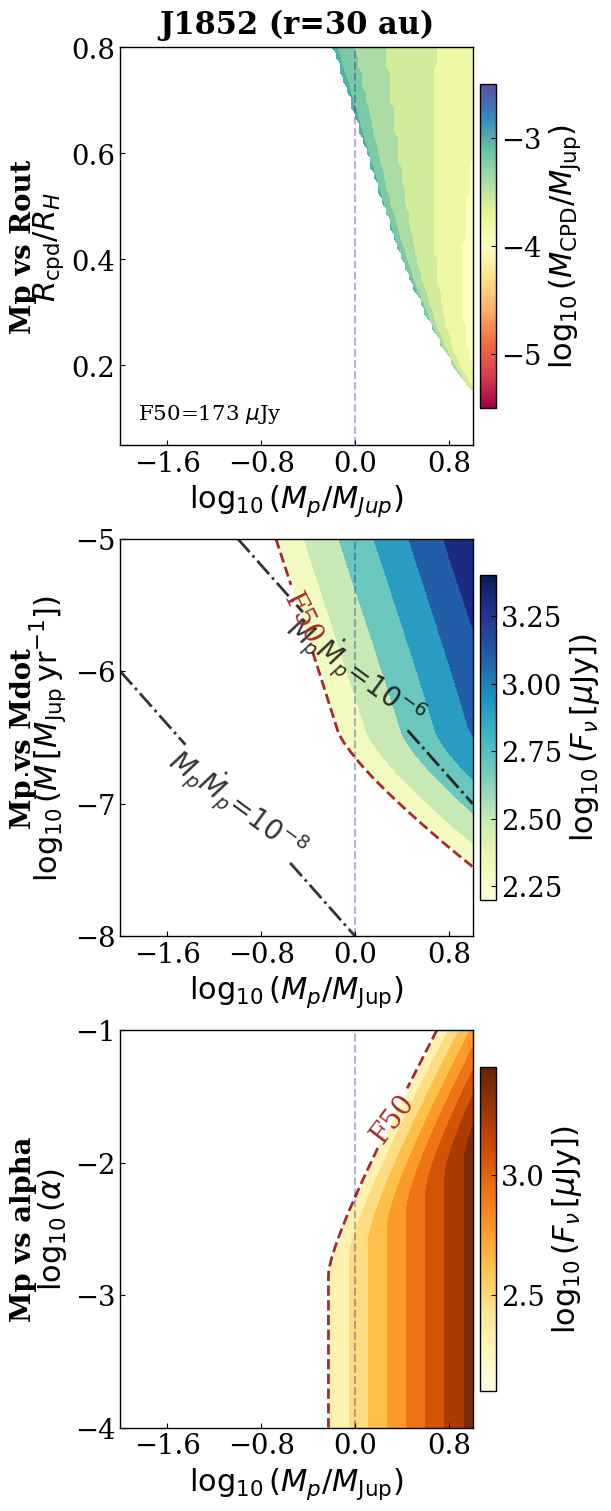

In [7]:
# CPD emission models for the top competing peak, plotted the same way as kink_emission_models.ipynb
# (plot_emission_grid): the peak's recovered flux (median brightest-pixel value in the search annulus,
# from recover_loop.py) is the target flux -- "what CPD would produce this peak" -- at the peak's
# disk-plane radius. Model grids are cached in CPD_Emission_Models/Andrews_npz (mode='competing_peak').
import json

nb_kink = json.load(open(r'D:\CPD_MPIA\CPD_Emission_Models\kink_emission_models.ipynb', encoding='utf-8'))
cwd = os.getcwd()
with plt.rc_context():
    exec(''.join(nb_kink['cells'][0]['source']))   # plot_emission_grid + grid helpers; chdirs to CPD_Emission_Models

    peak_folders = ['inner_cavity/J1852_gap0']
    # Format: [disk_name, radius_au, flux_ujy]
    peak_sources = [[top_peaks[f][0], round(top_peaks[f][2] * disk.disk[top_peaks[f][0]]['distance']), top_peaks[f][3]]
                    for f in peak_folders]
    # gap-boundary hatch: 2*wgap in au, as in kink_emission_models.ipynb
    peak_boundary_au = {(name, r_au): 2 * disk.disk[name]['wgap'][top_peaks[f][1]] * disk.disk[name]['distance']
                        for f, (name, r_au, _) in zip(peak_folders, peak_sources)}
    print(peak_sources)
    plot_emission_grid(peak_sources, mode='competing_peak', gap_boundary_au=peak_boundary_au)
os.chdir(cwd)